In [ ]:
from utils import get_xlsx_files,get_shp_files
from geomap import GeoMap
import pandas as pd

from dataprocess import kringing
from imageprocess import img_random_walk_process


element_label = "Al"

data = pd.read_excel(get_xlsx_files()["水稻点位148.xlsx"], sheet_name="原始数据")
gmap = GeoMap(get_shp_files()["湘潭县界.shp"])
gmap.load_dots_df(data)
kringing_path = kringing(data,num=100)
gmap.load_dots_df(pd.read_excel(kringing_path))
gmap.grid_paint(30, 30)
img_grid_path_grey = gmap.save_grid_image_grey(element_label)
img_grid_path_color = gmap.save_grid_image_color(element_label)
img_random_walk_path = img_random_walk_process(img_grid_path_color, img_grid_path_grey)

c:\Codes\agricultural-decision-system\.venv\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '有效态Cd' to '有效态C'
  ogr_write(


插值数据保存成功！


In [49]:
from matplotlib import pyplot as plt
import numpy as np
from skimage import io
import os

img_color = io.imread(img_grid_path_color)

# 加载图像
img_grey: np.ndarray = io.imread(img_grid_path_grey, as_gray=True)

In [50]:
img_grey = np.sqrt(1-img_grey)

In [51]:
non_zero_elements = img_grey[img_grey != 0]

In [52]:
low_threshold = np.percentile(non_zero_elements, 20)
high_threshold = np.percentile(non_zero_elements, 80)
low_threshold, high_threshold

(np.float64(0.15339299776947382), np.float64(0.28697202159177576))

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

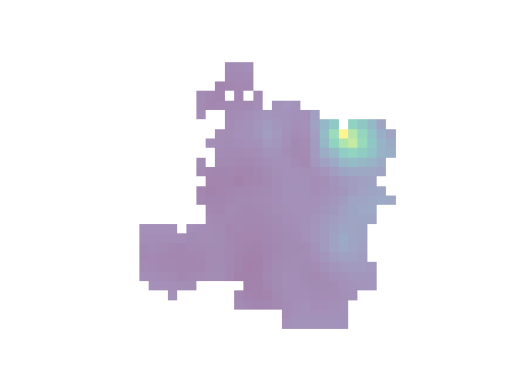

In [53]:
beta: int = 10
min_size: int = 100
dpi: int = 400
plt.imshow(img_color)
plt.axis('off')

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

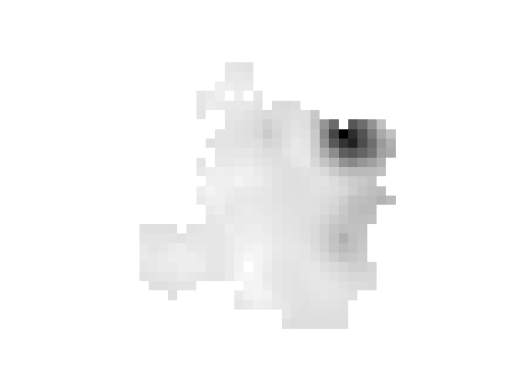

In [54]:
plt.imshow(img_grey, cmap="Greys")
plt.axis("off")

In [55]:
# markers: np.ndarray = np.zeros_like(img_grey)
# markers[img_grey > high_threshold] = 1
# markers[img_grey < low_threshold] = 0.5
# plt.imshow(markers, cmap="Greys")

In [56]:
from skimage.segmentation import random_walker

# 随机游走分割
markers: np.ndarray = np.zeros_like(img_grey)
markers[img_grey > high_threshold] = 1
markers[img_grey < low_threshold] = 2
seg_result = random_walker(img_grey, markers, beta=beta, mode="bf")

markers.min()

np.float64(0.0)

In [57]:
from skimage import morphology
from skimage.measure import label

# 区域处理，去除最小区域
label_img = label(seg_result)
filtered_regions = morphology.remove_small_objects(label_img, min_size)

In [58]:
# 二值化处理
prop_bw = filtered_regions
prop_bw[prop_bw == 1] = 0
prop_bw[prop_bw >= 1] = 1


In [59]:
# 骨架化
skeleton = morphology.skeletonize(prop_bw)

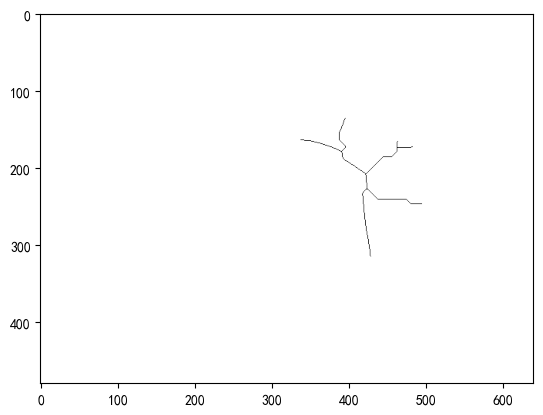

In [60]:
plt.imshow(skeleton,cmap='Greys')


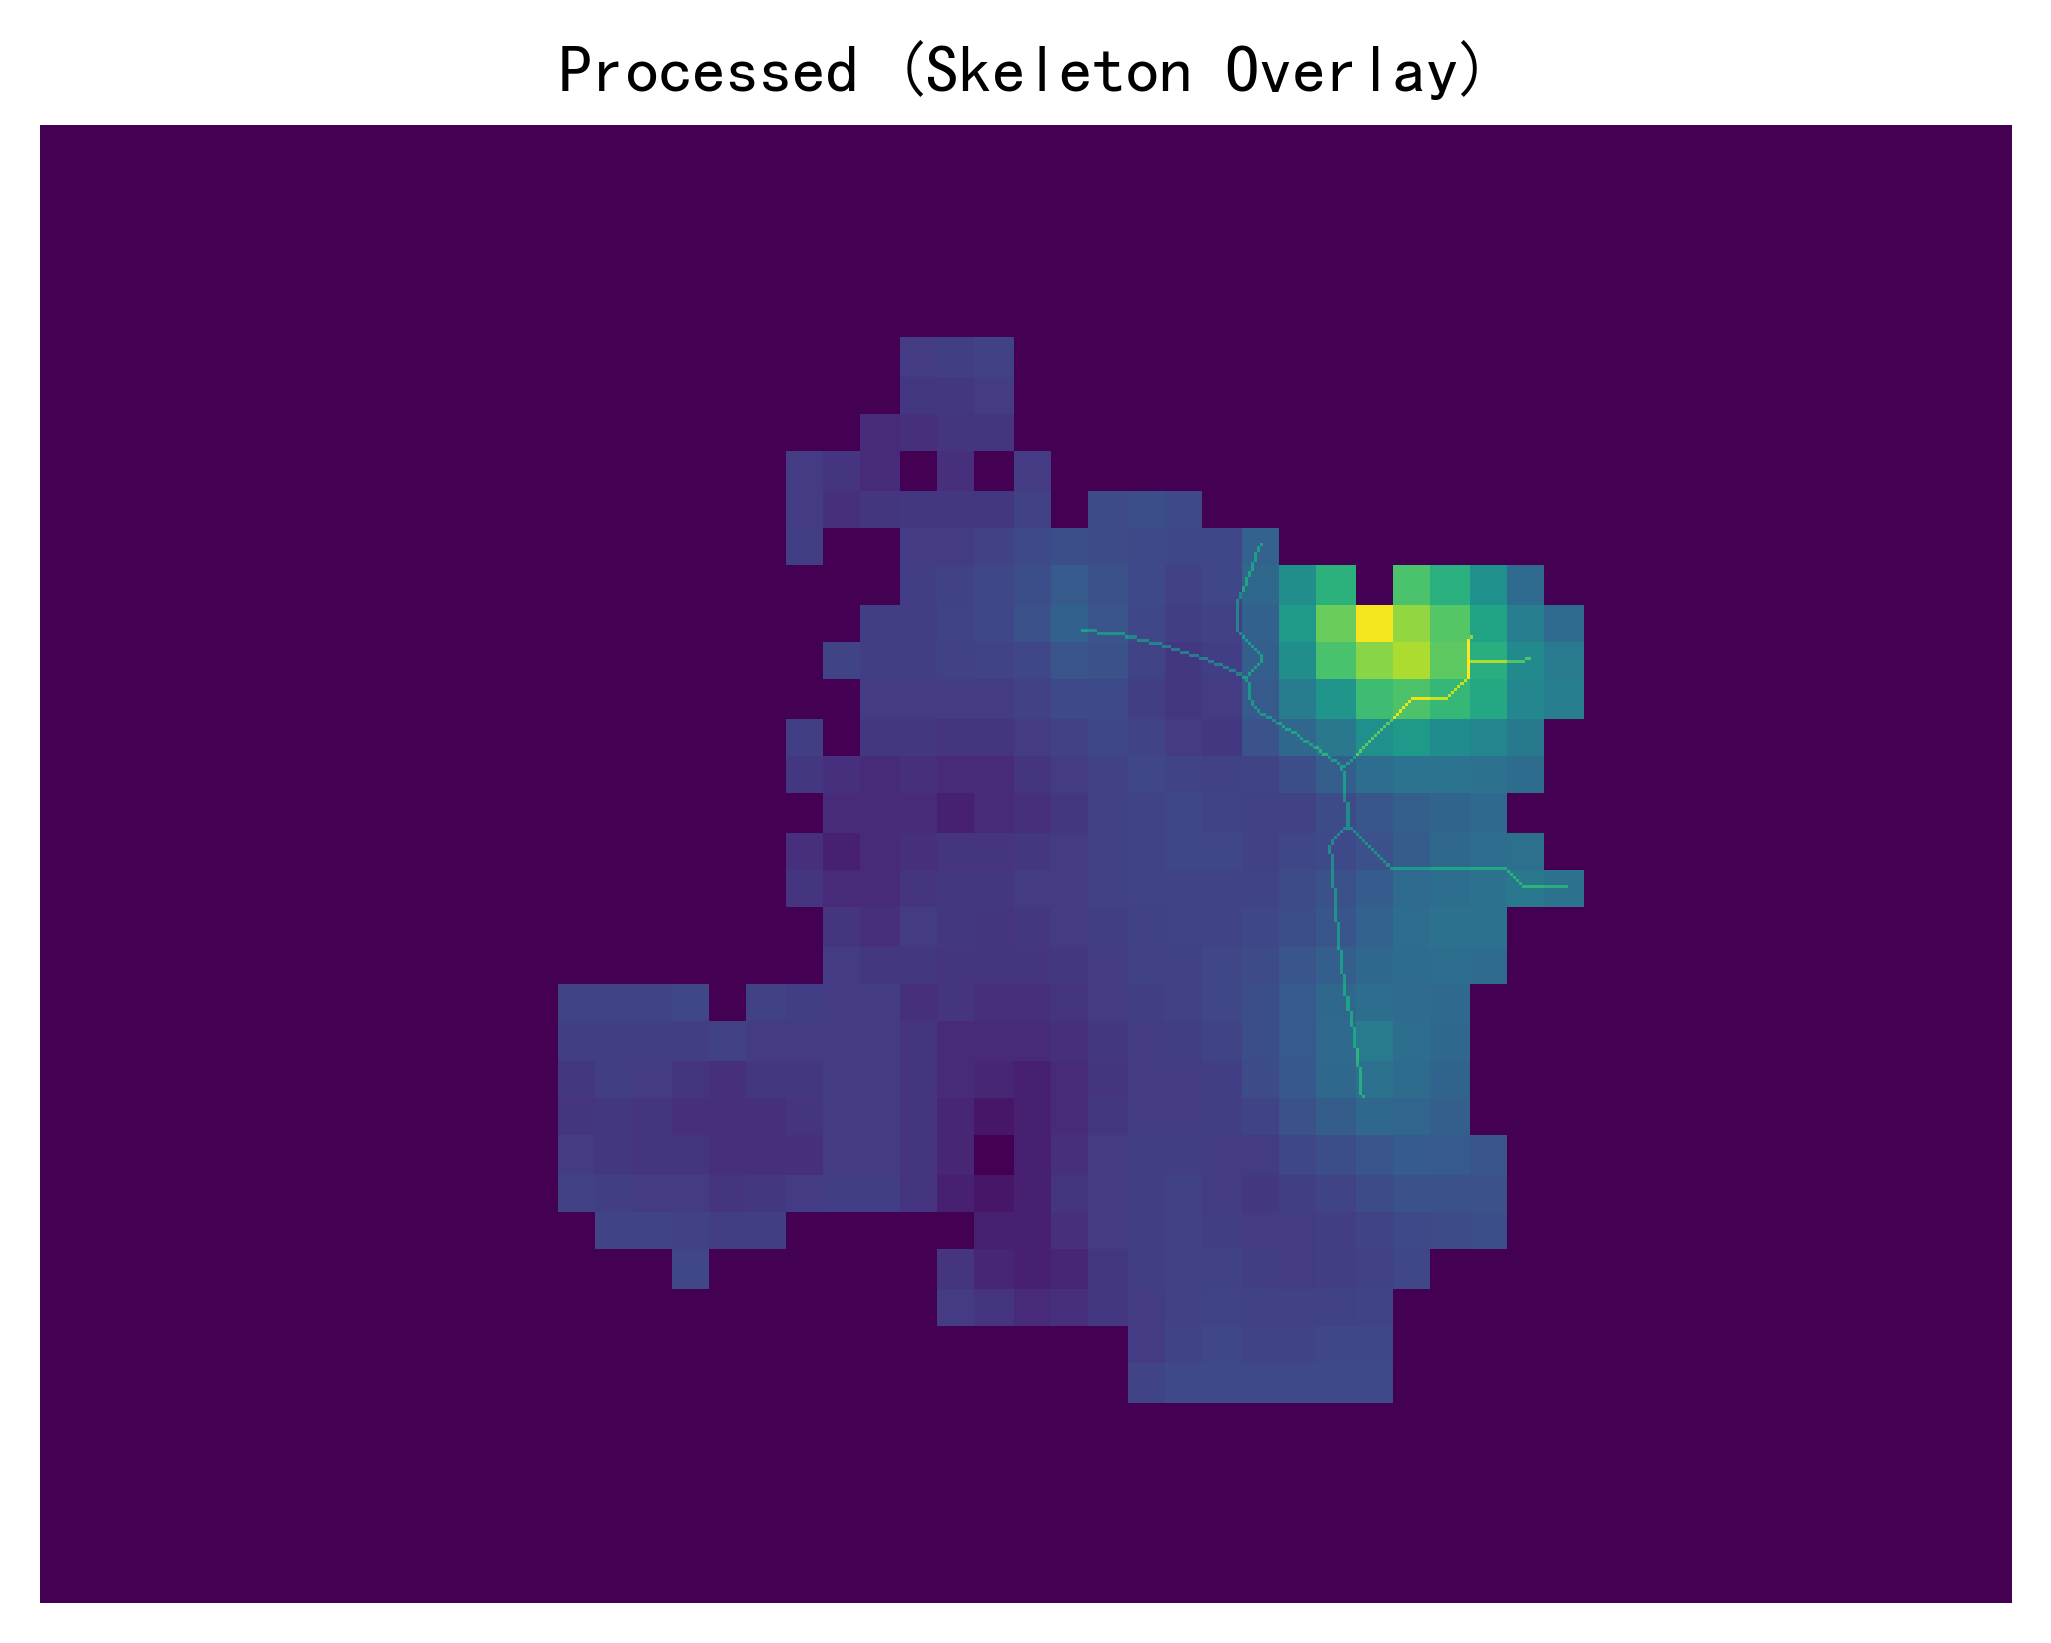

In [61]:
# 显示并保存结果
fig, ax = plt.subplots(dpi=dpi)

k = 0.8
ax.imshow(img_grey * k + np.double(skeleton) * (1 - k))
ax.axis("off")
ax.set_title("Processed (Skeleton Overlay)", fontsize=12)

file_path = os.path.join(".", "Images", "img_random_walk.png")

plt.show()

In [62]:
img_color[skeleton,:3] = [255,0,0]

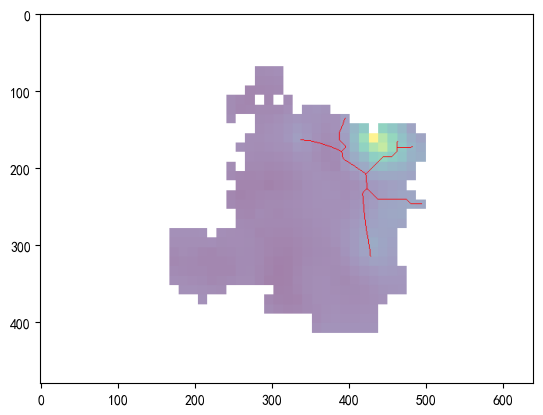

In [63]:
plt.imshow(img_color)